# HW12: Временные ряды, корректная валидация по времени, лаговые признаки и базовый прогноз с GRU.

## 2.3.1. Импорты, seed и среда

In [11]:
import math
import random
import json
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [24]:
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Фиксация seed
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

torch: 2.10.0+cpu
Device: cpu


## 2.3.2. Данные и первичный анализ

Число наблюдений: 4320
Диапазон дат: с 2025-01-01 00:00:00 по 2025-06-29 23:00:00

Пропуски:
date      0
target    0
dtype: int64

Статистика целевой переменной:


count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64

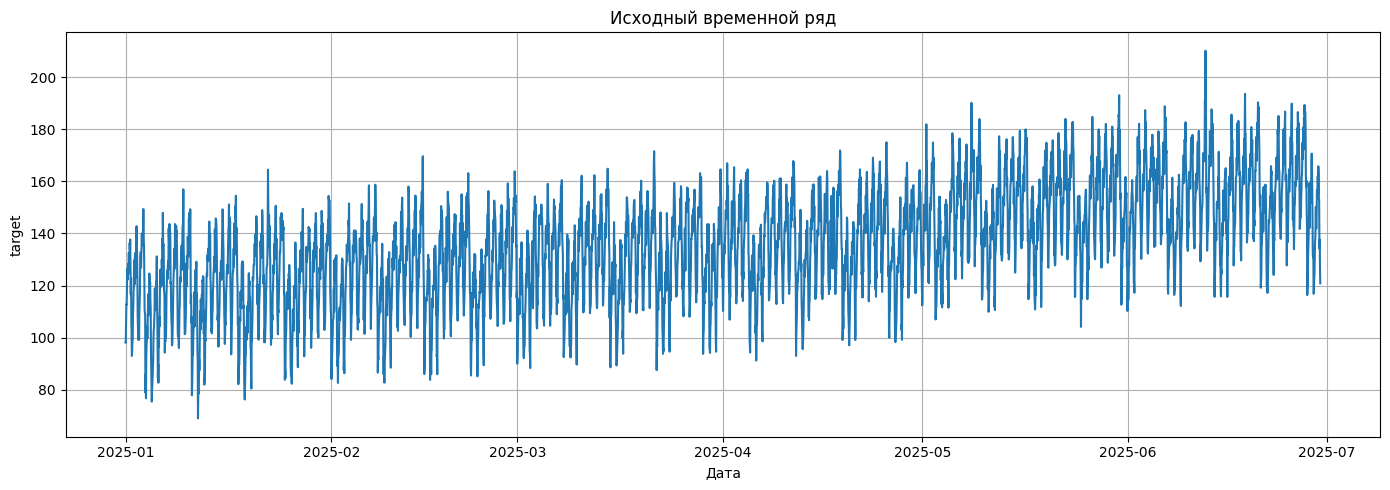

In [13]:
df = pd.read_csv("data/S12-hw-dataset.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

target_col = "target"
if target_col not in df.columns:
    raise ValueError(f"Колонка '{target_col}' не найдена. Доступные колонки: {df.columns.tolist()}")

print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: с {df['date'].min()} по {df['date'].max()}")
print("\nПропуски:")
print(df.isnull().sum())
print("\nСтатистика целевой переменной:")
display(df[target_col].describe())

# Визуализация ряда
fig, ax = plt.subplots()
ax.plot(df["date"], df[target_col], lw=1.5)
ax.set_title("Исходный временной ряд")
ax.set_xlabel("Дата")
ax.set_ylabel(target_col)
plt.tight_layout()
plt.savefig("artifacts/figures/original_series.png", dpi=100)
plt.show()


### Комментарий к ряду
- Ряд демонстрирует выраженный тренд (возможно, линейный).
- Наблюдается сезонность (недельная, так как видны регулярные колебания).
- Присутствуют выбросы (например, резкие скачки) и шум.
- Возможна нестационарность из-за тренда и изменяющейся волатильности.

## 2.3.3. Корректный temporal split

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


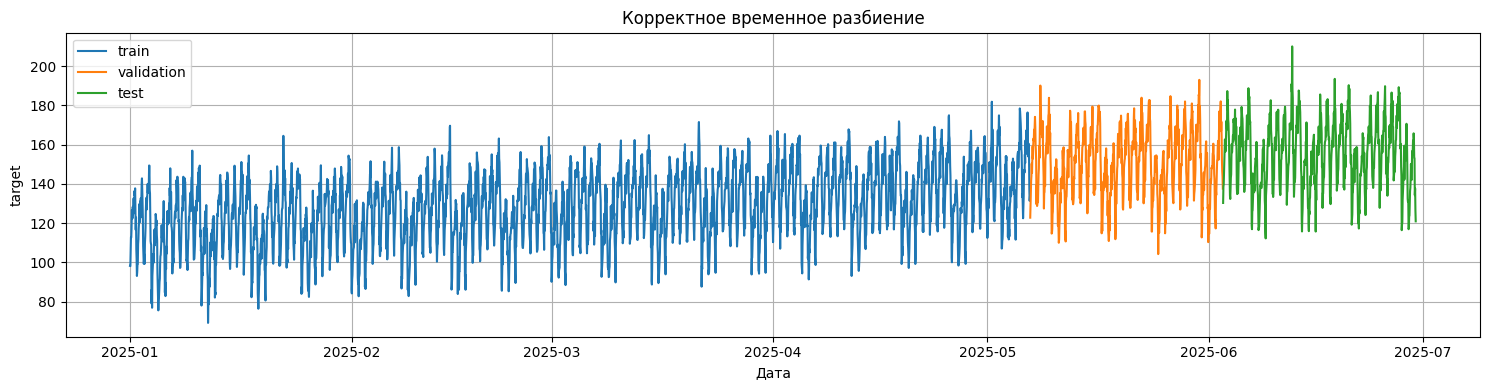

In [14]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    train = df.iloc[:train_end].copy()
    val = df.iloc[train_end:val_end].copy()
    test = df.iloc[val_end:].copy()
    return train, val, test

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

# Визуализация split
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df[target_col], label="train")
ax.plot(val_df["date"], val_df[target_col], label="validation")
ax.plot(test_df["date"], test_df[target_col], label="test")
ax.set_title("Корректное временное разбиение")
ax.set_xlabel("Дата")
ax.set_ylabel(target_col)
ax.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=100)
plt.show()


### Кратко объяснить, почему `random split` для данной задачи некорректен.

Случайное разбиение перемешивает наблюдения, что позволяет модели использовать информацию из будущего при обучении. В задачах прогнозирования временных рядов важно, чтобы модель обучалась только на прошлых данных и проверялась на будущих, поэтому необходимо хронологическое разбиение.

## 2.3.4. Признаки для baseline-моделей

In [15]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    out = df.copy()
    for lag in [1, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    # rolling окна с shift(1) для предотвращения утечки
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

feat_df = add_calendar_features(df)
feat_df = add_lag_features(feat_df, target_col)
feat_df = feat_df.dropna().reset_index(drop=True)

feature_cols = [
    "dayofweek", "month", "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7"
]

train_feat, val_feat, test_feat = temporal_split(feat_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]
X_val = val_feat[feature_cols]
y_val = val_feat[target_col]
X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности признаковых наборов:")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")

Размерности признаковых наборов:
X_train: (3014, 11) | y_train: (3014,)
X_val:   (646, 11) | y_val:   (646,)
X_test:  (646, 11) | y_test:  (646,)


## 2.3.5. Оконное представление для GRU

In [16]:
window_size = 28

# Масштабирование только на train
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[[target_col]]).astype(np.float32)
val_scaled = scaler.transform(val_df[[target_col]]).astype(np.float32)
test_scaled = scaler.transform(test_df[[target_col]]).astype(np.float32)

def make_windows(series_2d: np.ndarray, window_size: int):
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i:i+window_size])
        y.append(series_2d[i+window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_w, y_train_w = make_windows(train_scaled, window_size)
X_val_w, y_val_w = make_windows(val_scaled, window_size)
X_test_w, y_test_w = make_windows(test_scaled, window_size)

print(f"GRU train: {X_train_w.shape} | y: {y_train_w.shape}")
print(f"GRU val:   {X_val_w.shape} | y: {y_val_w.shape}")
print(f"GRU test:  {X_test_w.shape} | y: {y_test_w.shape}")

class TimeSeriesDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_ds = TimeSeriesDataset(X_train_w, y_train_w)
val_ds   = TimeSeriesDataset(X_val_w, y_val_w)
test_ds  = TimeSeriesDataset(X_test_w, y_test_w)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

GRU train: (2996, 28, 1) | y: (2996,)
GRU val:   (620, 28, 1) | y: (620,)
GRU test:  (620, 28, 1) | y: (620,)


## 2.3.6. Базовые функции обучения и оценки

In [17]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str = "") -> dict:
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * Xb.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_true = [], []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        pred = model(Xb)
        loss = criterion(pred, yb)
        total_loss += loss.item() * Xb.size(0)
        all_preds.append(pred.cpu().numpy())
        all_true.append(yb.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)
    return total_loss / len(loader.dataset), all_true, all_preds

## 3. Эксперименты

In [18]:
# 3.1. B1: naive-last (прогноз = последнее известное значение)
naive_pred_val = val_feat["lag_1"].to_numpy()
naive_pred_test = test_feat["lag_1"].to_numpy()

b1_val_metrics = evaluate_regression(y_val, naive_pred_val, "B1 (naive-last)")
b1_test_metrics = evaluate_regression(y_test, naive_pred_test, "B1 (naive-last)")

print("B1 validation:")
print(b1_val_metrics)
print("B1 test:")
print(b1_test_metrics)


B1 validation:
{'model': 'B1 (naive-last)', 'MAE': 6.4434055727554185, 'RMSE': 8.20353204909296, 'MAPE_%': 4.394593960122376}
B1 test:
{'model': 'B1 (naive-last)', 'MAE': 6.338018575851392, 'RMSE': 8.059905622137947, 'MAPE_%': 4.143508379000193}


In [19]:
# 3.2. B2: moving-average (окно 7)
ma_pred_val = val_feat["rolling_mean_7"].to_numpy()
ma_pred_test = test_feat["rolling_mean_7"].to_numpy()

b2_val_metrics = evaluate_regression(y_val, ma_pred_val, "B2 (moving-average)")
b2_test_metrics = evaluate_regression(y_test, ma_pred_test, "B2 (moving-average)")

print("B2 validation:")
print(b2_val_metrics)
print("B2 test:")
print(b2_test_metrics)


B2 validation:
{'model': 'B2 (moving-average)', 'MAE': 12.723717381689518, 'RMSE': 15.236325500475134, 'MAPE_%': 8.82877937382802}
B2 test:
{'model': 'B2 (moving-average)', 'MAE': 12.725249889429454, 'RMSE': 15.226178942983882, 'MAPE_%': 8.534403399898007}


In [20]:
# 3.3. B3: Ridge на лаговых, rolling и календарных признаках
scaler_features = StandardScaler()
X_train_scaled = scaler_features.fit_transform(X_train)
X_val_scaled = scaler_features.transform(X_val)
X_test_scaled = scaler_features.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_val_pred_ridge = ridge.predict(X_val_scaled)
b3_val_metrics = evaluate_regression(y_val, y_val_pred_ridge, "B3 (ridge-lag-features)")

y_test_pred_ridge = ridge.predict(X_test_scaled)
b3_test_metrics = evaluate_regression(y_test, y_test_pred_ridge, "B3 (ridge-lag-features)")

print("B3 validation:")
print(b3_val_metrics)
print("B3 test:")
print(b3_test_metrics)


B3 validation:
{'model': 'B3 (ridge-lag-features)', 'MAE': 6.441300904185838, 'RMSE': 7.944266106169769, 'MAPE_%': 4.304582477526816}
B3 test:
{'model': 'B3 (ridge-lag-features)', 'MAE': 5.414188095604287, 'RMSE': 6.927580160914474, 'MAPE_%': 3.5194324613690835}


Epoch 01 | train_loss=0.5076 | val_loss=0.2875 | val_mae=8.0586
Epoch 02 | train_loss=0.1627 | val_loss=0.2111 | val_mae=6.9220
Epoch 03 | train_loss=0.1510 | val_loss=0.1964 | val_mae=6.6503
Epoch 04 | train_loss=0.1504 | val_loss=0.2014 | val_mae=6.7361
Epoch 05 | train_loss=0.1477 | val_loss=0.1734 | val_mae=6.1046
Epoch 06 | train_loss=0.1474 | val_loss=0.2219 | val_mae=7.1022
Epoch 07 | train_loss=0.1442 | val_loss=0.1961 | val_mae=6.5975
Epoch 08 | train_loss=0.1429 | val_loss=0.1922 | val_mae=6.5234
Epoch 09 | train_loss=0.1322 | val_loss=0.2569 | val_mae=7.5869
Epoch 10 | train_loss=0.1190 | val_loss=0.2106 | val_mae=6.8004
Epoch 11 | train_loss=0.1106 | val_loss=0.1849 | val_mae=6.2519
Epoch 12 | train_loss=0.1054 | val_loss=0.1954 | val_mae=6.4391
Epoch 13 | train_loss=0.1022 | val_loss=0.1512 | val_mae=5.5709
Epoch 14 | train_loss=0.1023 | val_loss=0.1633 | val_mae=5.8158
Epoch 15 | train_loss=0.1022 | val_loss=0.2095 | val_mae=6.6115
Epoch 16 | train_loss=0.1003 | val_loss=

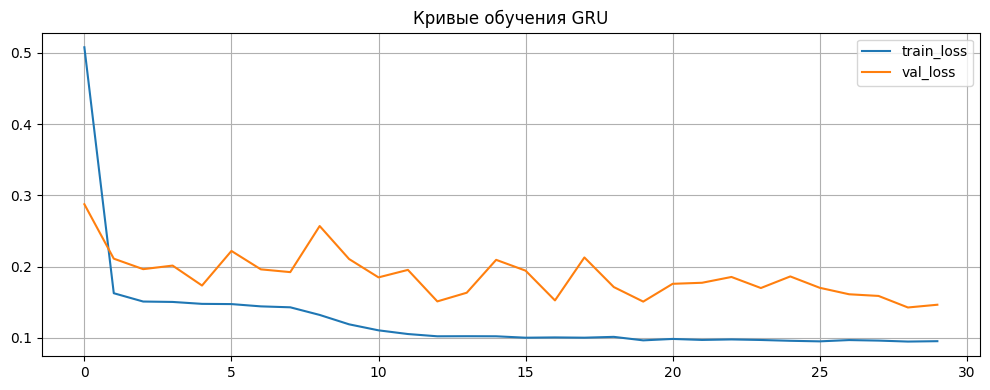

In [21]:
# 3.4. R1: GRU на оконном представлении
class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.fc(last).squeeze(-1)

model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

num_epochs = 30
best_val_mae = float("inf")           # изменено: теперь храним лучший MAE
best_state = None
history = {"train_loss": [], "val_loss": [], "val_mae": []}   # добавили val_mae

for epoch in range(1, num_epochs+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Получаем предсказания на валидации (масштабированные)
    val_loss, y_val_scaled_true, y_val_scaled_pred = evaluate_model(model, val_loader, criterion, device)

    # Преобразуем обратно в исходный масштаб
    y_val_true = scaler.inverse_transform(y_val_scaled_true.reshape(-1, 1)).ravel()
    y_val_pred = scaler.inverse_transform(y_val_scaled_pred.reshape(-1, 1)).ravel()

    # Считаем MAE на валидации
    val_mae = mean_absolute_error(y_val_true, y_val_pred)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)

    # Сохраняем модель, если MAE улучшился
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict().copy()

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_mae={val_mae:.4f}")

model.load_state_dict(best_state)

_, y_val_scaled_pred, y_val_scaled_true = evaluate_model(model, val_loader, criterion, device)
y_val_pred = scaler.inverse_transform(y_val_scaled_pred.reshape(-1,1)).ravel()
y_val_true = scaler.inverse_transform(y_val_scaled_true.reshape(-1,1)).ravel()
b4_val_metrics = evaluate_regression(y_val_true, y_val_pred, "R1 (gru-forecast)")

# Оценка на тесте (один раз, для финального отчёта)
_, y_test_scaled_pred, y_test_scaled_true = evaluate_model(model, test_loader, criterion, device)
y_test_pred = scaler.inverse_transform(y_test_scaled_pred.reshape(-1,1)).ravel()
y_test_true = scaler.inverse_transform(y_test_scaled_true.reshape(-1,1)).ravel()
b4_test_metrics = evaluate_regression(y_test_true, y_test_pred, "R1 (gru-forecast)")

print("R1 validation:")
print(b4_val_metrics)
print("R1 test:")
print(b4_test_metrics)

# Кривые обучения
plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Кривые обучения GRU")
plt.tight_layout()
plt.savefig("artifacts/figures/gru_learning_curves.png", dpi=100)
plt.show()

## 5. Сохранение артефактов

In [22]:
#Сборка результатов в runs.csv
all_results = []

# B1
all_results.append({
    "experiment_id": "B1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset",
    "seed": 42,
    "split_summary": f"train:{len(X_train)} val:{len(X_val)} test:{len(X_test)}",
    "window_size": None,
    "horizon": 1,
    "model_summary": "Naive last (lag_1)",
    "features_summary": "None",
    "scaler": "None",
    "optimizer": "None",
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": b1_val_metrics["MAE"],
    "best_val_rmse": b1_val_metrics["RMSE"],
    "best_val_mape": b1_val_metrics["MAPE_%"],
    "test_mae": b1_test_metrics["MAE"],
    "test_rmse": b1_test_metrics["RMSE"],
    "test_mape": b1_test_metrics["MAPE_%"],
    "notes": "baseline"
})

# B2
all_results.append({
    "experiment_id": "B2",
    "task": "forecasting",
    "dataset": "S12-hw-dataset",
    "seed": 42,
    "split_summary": f"train:{len(X_train)} val:{len(X_val)} test:{len(X_test)}",
    "window_size": 7,
    "horizon": 1,
    "model_summary": "Moving average (window=7)",
    "features_summary": "rolling_mean_7",
    "scaler": "None",
    "optimizer": "None",
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": b2_val_metrics["MAE"],
    "best_val_rmse": b2_val_metrics["RMSE"],
    "best_val_mape": b2_val_metrics["MAPE_%"],
    "test_mae": b2_test_metrics["MAE"],
    "test_rmse": b2_test_metrics["RMSE"],
    "test_mape": b2_test_metrics["MAPE_%"],
    "notes": "baseline"
})

# B3
all_results.append({
    "experiment_id": "B3",
    "task": "forecasting",
    "dataset": "S12-hw-dataset",
    "seed": 42,
    "split_summary": f"train:{len(X_train)} val:{len(X_val)} test:{len(X_test)}",
    "window_size": None,
    "horizon": 1,
    "model_summary": "Ridge(alpha=1.0)",
    "features_summary": ",".join(feature_cols),
    "scaler": "StandardScaler",
    "optimizer": "None",
    "lr": None,
    "epochs_trained": None,
    "best_val_mae": b3_val_metrics["MAE"],
    "best_val_rmse": b3_val_metrics["RMSE"],
    "best_val_mape": b3_val_metrics["MAPE_%"],
    "test_mae": b3_test_metrics["MAE"],
    "test_rmse": b3_test_metrics["RMSE"],
    "test_mape": b3_test_metrics["MAPE_%"],
    "notes": "ridge with lags+rolling+calendar"
})

# R1
all_results.append({
    "experiment_id": "R1",
    "task": "forecasting",
    "dataset": "S12-hw-dataset",
    "seed": 42,
    "split_summary": f"train:{len(X_train_w)} val:{len(X_val_w)} test:{len(X_test_w)}",
    "window_size": window_size,
    "horizon": 1,
    "model_summary": "GRU(hidden=64, layers=2)",
    "features_summary": "raw series (windowed)",
    "scaler": "StandardScaler (target only)",
    "optimizer": "Adam",
    "lr": 1e-3,
    "epochs_trained": num_epochs,
    "best_val_mae": b4_val_metrics["MAE"],
    "best_val_rmse": b4_val_metrics["RMSE"],
    "best_val_mape": b4_val_metrics["MAPE_%"],
    "test_mae": b4_test_metrics["MAE"],
    "test_rmse": b4_test_metrics["RMSE"],
    "test_mape": b4_test_metrics["MAPE_%"],
    "notes": "gru forecast, best model by val_mae"
})

results_df = pd.DataFrame(all_results)
results_df.to_csv("artifacts/runs.csv", index=False)
display(results_df)
# Сохраняем лучшую модель GRU

torch.save(best_state, "artifacts/best_gru.pt")

# Конфиг модели
config = {
    "model_type": "GRUForecaster",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "window_size": window_size,
    "batch_size": batch_size,
    "learning_rate": 1e-3,
    "num_epochs": num_epochs,
    "seed": 42,
    "scaler_mean": scaler.mean_[0].tolist(),
    "scaler_scale": scaler.scale_[0].tolist(),
}
with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Артефакты сохранены: runs.csv, best_gru.pt, best_gru_config.json")


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,train:3014 val:646 test:646,NaN,1,Naive last (lag_1),None,None,None,NaN,NaN,6.443406,8.203532,4.394594,6.338019,8.059906,4.143508,baseline
1,B2,forecasting,S12-hw-dataset,42,train:3014 val:646 test:646,7.0,1,Moving average (window=7),rolling_mean_7,None,None,NaN,NaN,12.723717,15.236326,8.828779,12.725250,15.226179,8.534403,baseline
2,B3,forecasting,S12-hw-dataset,42,train:3014 val:646 test:646,NaN,1,Ridge(alpha=1.0),"dayofweek,month,dow_sin,dow_cos,month_sin,mont...",StandardScaler,None,NaN,NaN,6.441301,7.944266,4.304582,5.414188,6.927580,3.519432,ridge with lags+rolling+calendar
3,R1,forecasting,S12-hw-dataset,42,train:2996 val:620 test:620,28.0,1,"GRU(hidden=64, layers=2)",raw series (windowed),StandardScaler (target only),Adam,0.001,30.0,5.459908,7.073833,3.825193,6.205029,7.919656,4.227300,"gru forecast, best model by val_mae"


Артефакты сохранены: runs.csv, best_gru.pt, best_gru_config.json


### Визуализация сравнения моделей и прогноза

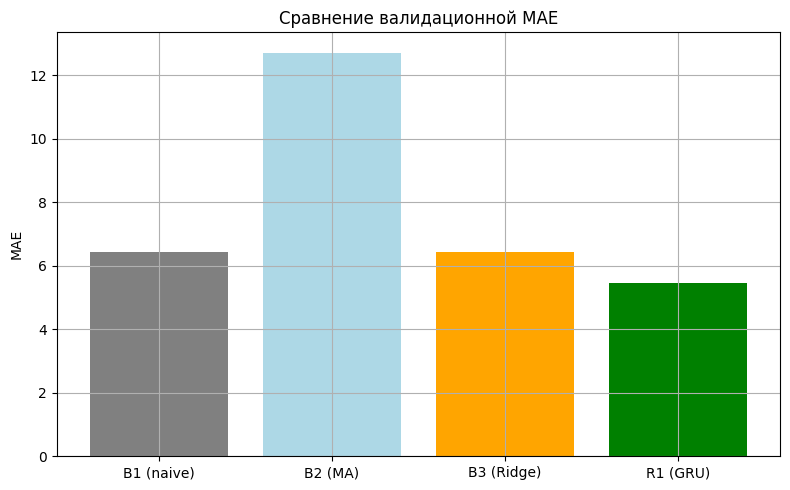

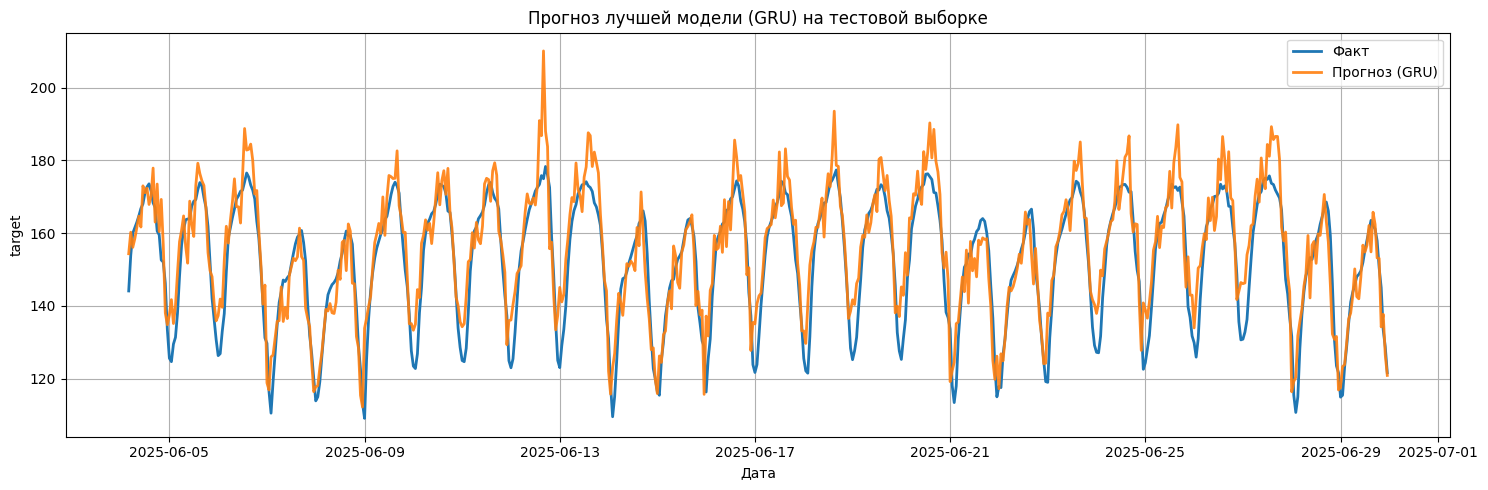

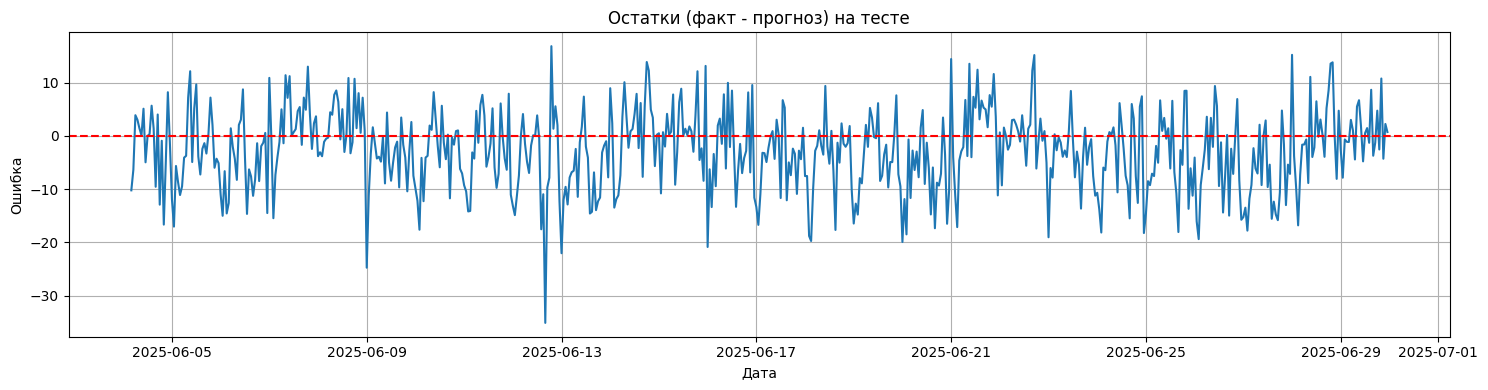

In [23]:
# Сравнение валидационных MAE
metrics_vals = {
    "B1 (naive)": b1_val_metrics["MAE"],
    "B2 (MA)": b2_val_metrics["MAE"],
    "B3 (Ridge)": b3_val_metrics["MAE"],
    "R1 (GRU)": b4_val_metrics["MAE"],
}
plt.figure(figsize=(8,5))
plt.bar(metrics_vals.keys(), metrics_vals.values(), color=['gray','lightblue','orange','green'])
plt.ylabel("MAE")
plt.title("Сравнение валидационной MAE")
plt.tight_layout()
plt.savefig("artifacts/figures/baselines_compare.png", dpi=100)
plt.show()

# Прогноз лучшей модели на тесте (R1)
test_dates = test_df["date"].iloc[window_size:].reset_index(drop=True)

plt.figure(figsize=(15,5))
plt.plot(test_dates, y_test_true, label="Факт", lw=2)
plt.plot(test_dates, y_test_pred, label="Прогноз (GRU)", lw=2, alpha=0.9)
plt.title("Прогноз лучшей модели (GRU) на тестовой выборке")
plt.xlabel("Дата")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/best_forecast_test.png", dpi=100)
plt.show()

# Остатки
residuals = y_test_true - y_test_pred
plt.figure(figsize=(15,4))
plt.plot(test_dates, residuals, lw=1.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Остатки (факт - прогноз) на тесте")
plt.xlabel("Дата")
plt.ylabel("Ошибка")
plt.tight_layout()
plt.savefig("artifacts/figures/residuals_best.png", dpi=100)
plt.show()